# 02 — Línea base clásica: SVM-RBF

Este notebook es el **registro de ejecución** de las Partes 1 y 2 del enunciado (preparación de
datos y línea base clásica). No duplica lógica: llama directamente a las funciones de
`src/data_prep/prepare_data.py` y `src/classical/baseline.py`, que son la fuente de verdad
reproducible. Ejecutar este notebook de principio a fin regenera:

- `data/processed/` (train/test imputado, estandarizado y balanceado)
- `data/quantum_subset/` (subconjuntos de 16/32/64 muestras para la Parte 3)
- `results/metrics/classical_baseline.json`
- `results/figures/fig_confusion_matrix_classical.png`

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data_prep import prepare_data
from src.classical import baseline

## Paso 1 — Preparación de datos (Parte 1)

Orden a prueba de fuga de datos: split estratificado 80/20 primero, luego imputación por
mediana por clase (mediana calculada solo con train), estandarización (fit solo con train),
balanceo por submuestreo (solo en train), y selección de subconjuntos balanceados de
16/32/64 muestras **desde el train balanceado**, nunca desde test.

`prepare_data.main()` ejecuta todo el pipeline y escribe los artefactos en
`data/processed/` y `data/quantum_subset/`.

In [2]:
prepare_data.main()

Train (balanced): (2044, 9) | Test: (656, 9)
Train class counts (balanced): {0: 1022, 1: 1022}
Test class counts: {0: 400, 1: 256}
Quantum subsets written for sizes: (16, 32, 64)


In [3]:
import json

with open(prepare_data.PROCESSED_DIR / "metadata.json") as f:
    processed_metadata = json.load(f)
processed_metadata

{'seed': 42,
 'test_size': 0.2,
 'balance_method': 'undersample',
 'train_size_before_balance': 2620,
 'train_size_after_balance': 2044,
 'test_size_n': 656,
 'class_counts_train_before_balance': {'0': 1598, '1': 1022},
 'class_counts_train_after_balance': {'0': 1022, '1': 1022},
 'class_counts_test': {'0': 400, '1': 256},
 'imputation_medians_by_class': {'0': {'ph': 7.013539744397472,
   'Hardness': 196.5954140214223,
   'Solids': 20717.10506073064,
   'Chloramines': 7.103510578912478,
   'Sulfate': 333.1483176590248,
   'Conductivity': 424.47130181708735,
   'Organic_carbon': 14.215790896505126,
   'Trihalomethanes': 66.28481945089318,
   'Turbidity': 3.975469385069254},
  '1': {'ph': 7.063646975622253,
   'Hardness': 197.54220207030636,
   'Solids': 21150.782365789513,
   'Chloramines': 7.1449952666023595,
   'Sulfate': 332.9363746084408,
   'Conductivity': 425.51786735389294,
   'Organic_carbon': 14.202889133733294,
   'Trihalomethanes': 66.68609327475363,
   'Turbidity': 3.9661262

## Paso 2 — Línea base SVM-RBF (Parte 2)

`baseline.train_and_evaluate` ejecuta `GridSearchCV` sobre la grilla completa
`C ∈ {0.1, 1, 10} × gamma ∈ {scale, auto, 0.01}` (9 combinaciones), cada una evaluada con
**CV de 5 particiones** → 9 × 5 = **45 entrenamientos de SVM** durante la búsqueda, más
**1 reentrenamiento final** sobre todo el train balanceado con los mejores hiperparámetros
(`refit=True` por defecto en `GridSearchCV`) → **46 SVM entrenadas en total**. Solo ese modelo
final se evalúa, una vez, sobre el test set reservado.

In [4]:
X_train, X_test, y_train, y_test = baseline.load_processed()
best_model, metrics = baseline.train_and_evaluate(X_train, y_train, X_test, y_test)
metrics

{'best_params': {'C': 10, 'gamma': 'auto'},
 'cv_best_f1': 0.6263236127106935,
 'accuracy': 0.600609756097561,
 'precision': 0.48863636363636365,
 'recall': 0.50390625,
 'f1': 0.49615384615384617,
 'confusion_matrix': [[265, 135], [127, 129]]}

## Guardar métricas y matriz de confusión

Reutiliza `baseline.plot_confusion_matrix`, la misma función que usa el punto de entrada por
terminal, para que la figura sea idéntica sin importar cómo se ejecute el pipeline.

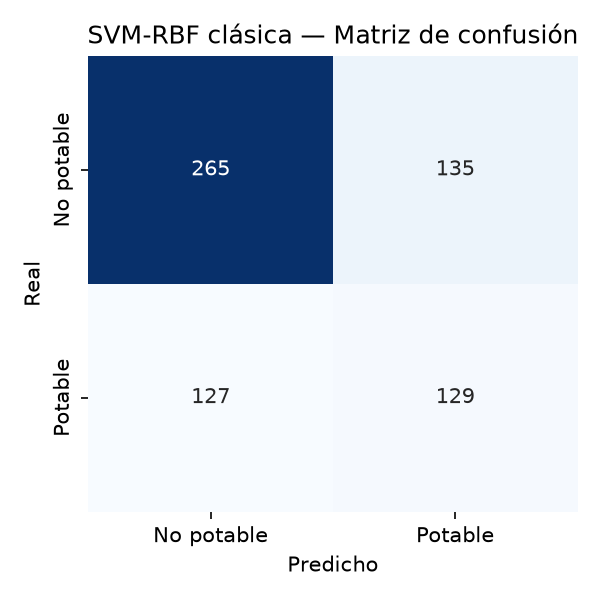

In [5]:
baseline.METRICS_DIR.mkdir(parents=True, exist_ok=True)
baseline.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(baseline.METRICS_DIR / "classical_baseline.json", "w") as f:
    json.dump(metrics, f, indent=2)

cm_path = baseline.FIGURES_DIR / "fig_confusion_matrix_classical.png"
baseline.plot_confusion_matrix(metrics["confusion_matrix"], cm_path)

from IPython.display import Image, display
display(Image(filename=str(cm_path)))

## Interpretación

- Mejores hiperparámetros y F1 promedio de CV vs. F1 en el test set reservado (compararlos:
  si el de CV es notablemente más alto que el de test, hay señal de sobreajuste a los folds).
- Estas cinco métricas (exactitud, precisión, recall, F1, matriz de confusión) son la referencia
  fija contra la que se compara la QSVM en `03_quantum_kernel.ipynb` y `04_feature_map_study.ipynb`
  — mismo test set, mismas definiciones de métrica, para que la comparación sea justa.

In [6]:
print(f"CV best F1 (5-fold, grid search): {metrics['cv_best_f1']:.3f}")
print(f"Test accuracy:  {metrics['accuracy']:.3f}")
print(f"Test precision: {metrics['precision']:.3f}")
print(f"Test recall:    {metrics['recall']:.3f}")
print(f"Test F1:        {metrics['f1']:.3f}")
print(f"Best params:    {metrics['best_params']}")

CV best F1 (5-fold, grid search): 0.626
Test accuracy:  0.601
Test precision: 0.489
Test recall:    0.504
Test F1:        0.496
Best params:    {'C': 10, 'gamma': 'auto'}


## Paso 3 — Baseline clásico extendido (Optuna + balanceo dentro de CV)

La línea base de arriba (Parte 2, requisito de rúbrica) usa la grilla fija `C x gamma` sobre datos ya balanceados por submuestreo *antes* de la validación cruzada. Dos mejoras que exploramos aquí, sin tocar la línea base anterior:

1. **Balanceo dentro de cada fold de CV, no antes.** Se usa `data/processed/X_train_raw.csv` (imputado y estandarizado, SIN balancear) junto con un `imblearn.pipeline.Pipeline` que aplica el resampler (submuestreo / SMOTE / o `class_weight='balanced'` sin resamplear) *dentro* de cada fold de entrenamiento. Balancear antes de la CV puede filtrar información (sobre todo con SMOTE, donde puntos sintéticos de un fold pueden depender de vecinos que terminan en el fold de validación) e infla la estimación de CV de forma artificial.
2. **Búsqueda de hiperparámetros con Optuna** (TPE, muestreo bayesiano) sobre `C` y `gamma` en escala logarítmica continua, más la estrategia de balanceo como hiperparámetro adicional — en vez de la grilla fija de 9 combinaciones.

Este modelo optimizado es el que usaremos como **"clasificador clásico más fuerte"** para la comparación con la QSVM (criterio general de la rúbrica: *"la comparación debe hacerse frente al método clásico más fuerte disponible"*), manteniendo el baseline de grilla fija de arriba como el entregable específico y literal de la Parte 2.

In [7]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.classical import optuna_search

best_pipeline, optuna_metrics, study = optuna_search.main(n_trials=60)

{
  "best_params": {
    "C": 1.4406430486702142,
    "gamma": "auto",
    "balance_strategy": "class_weight"
  },
  "cv_best_f1_mean": 0.5752808322666451,
  "cv_f1_std": 0.11748910728703539,
  "n_trials": 60,
  "cv_scheme": "RepeatedStratifiedKFold(n_splits=5, n_repeats=3)",
  "accuracy": 0.6219512195121951,
  "precision": 0.5158730158730159,
  "recall": 0.5078125,
  "f1": 0.5118110236220472,
  "confusion_matrix": [
    [
      278,
      122
    ],
    [
      126,
      130
    ]
  ]
}


### Comparación: baseline de grilla fija vs. baseline optimizado (Optuna)

In [8]:
import pandas as pd

comparison = pd.DataFrame({
    "Grid-search (Parte 2, requerido)": {
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "cv_f1": metrics["cv_best_f1"],
    },
    "Optuna-optimizado (extendido)": {
        "accuracy": optuna_metrics["accuracy"],
        "precision": optuna_metrics["precision"],
        "recall": optuna_metrics["recall"],
        "f1": optuna_metrics["f1"],
        "cv_f1": optuna_metrics["cv_best_f1_mean"],
    },
}).T
comparison

,accuracy,precision,recall,f1,cv_f1
"Grid-search (Parte 2, requerido)",0.600610,0.488636,0.503906,0.496154,0.626324
Optuna-optimizado (extendido),0.621951,0.515873,0.507812,0.511811,0.575281


## Visualización: proyección PCA 2D + frontera de decisión real de la SVM

Los datos tienen 9 dimensiones, así que no se puede graficar la frontera de decisión
directamente. En vez de entrenar un modelo "de juguete" en 2D (lo cual mostraría la frontera de
un clasificador distinto), proyectamos con **PCA a 2 componentes** y evaluamos la
`decision_function` del **modelo real ya entrenado en 9D** sobre una malla en el plano
PC1-PC2 (cada punto de la malla se reconstruye a 9D vía `PCA.inverse_transform` antes de
pasarlo al modelo). El contorno resultante es la frontera real del clasificador, restringida al
plano de mayor varianza — no una aproximación con un modelo distinto.

Varianza explicada por PC1+PC2: 27.6%


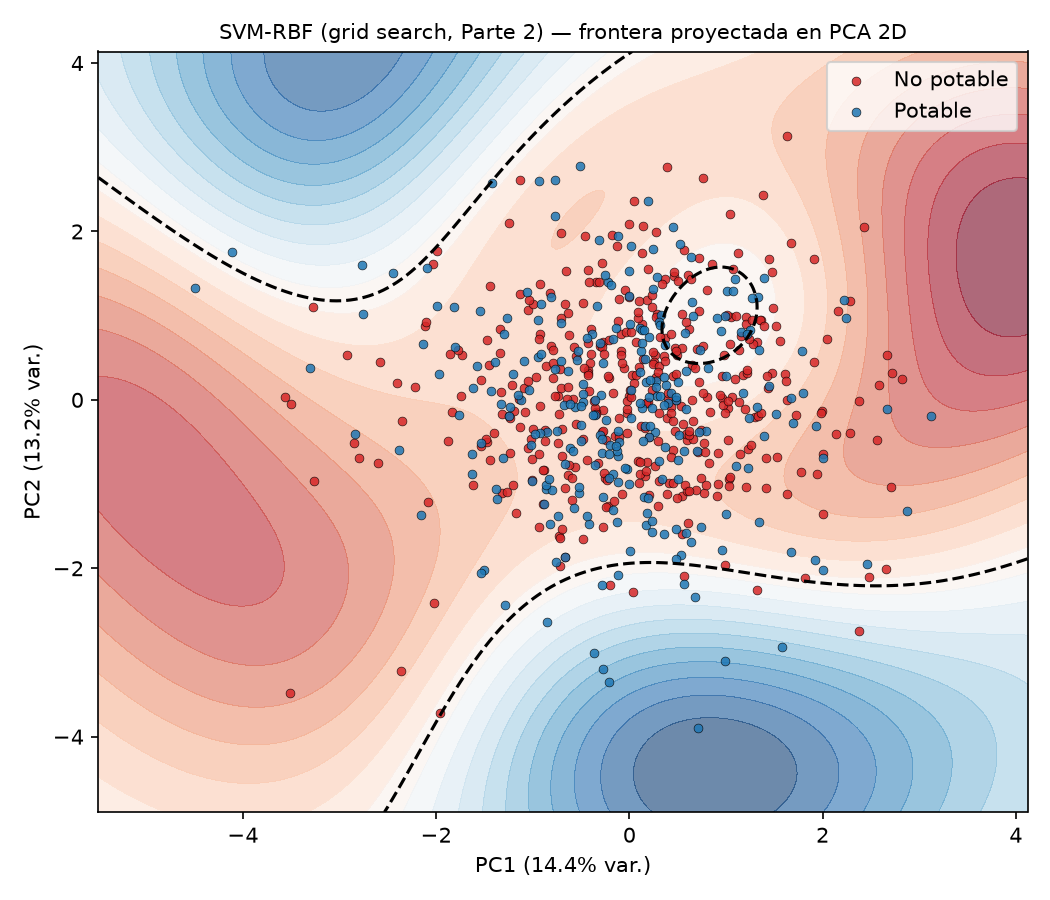

In [9]:
from src.utils.plotting import plot_2d_decision_boundary

grid_boundary_path = baseline.FIGURES_DIR / "fig_decision_boundary_grid_pca.png"
explained_grid = plot_2d_decision_boundary(
    best_model, X_test, y_test,
    "SVM-RBF (grid search, Parte 2) — frontera proyectada en PCA 2D",
    grid_boundary_path,
)
print(f"Varianza explicada por PC1+PC2: {explained_grid.sum():.1%}")
display(Image(filename=str(grid_boundary_path)))

Varianza explicada por PC1+PC2: 27.6%


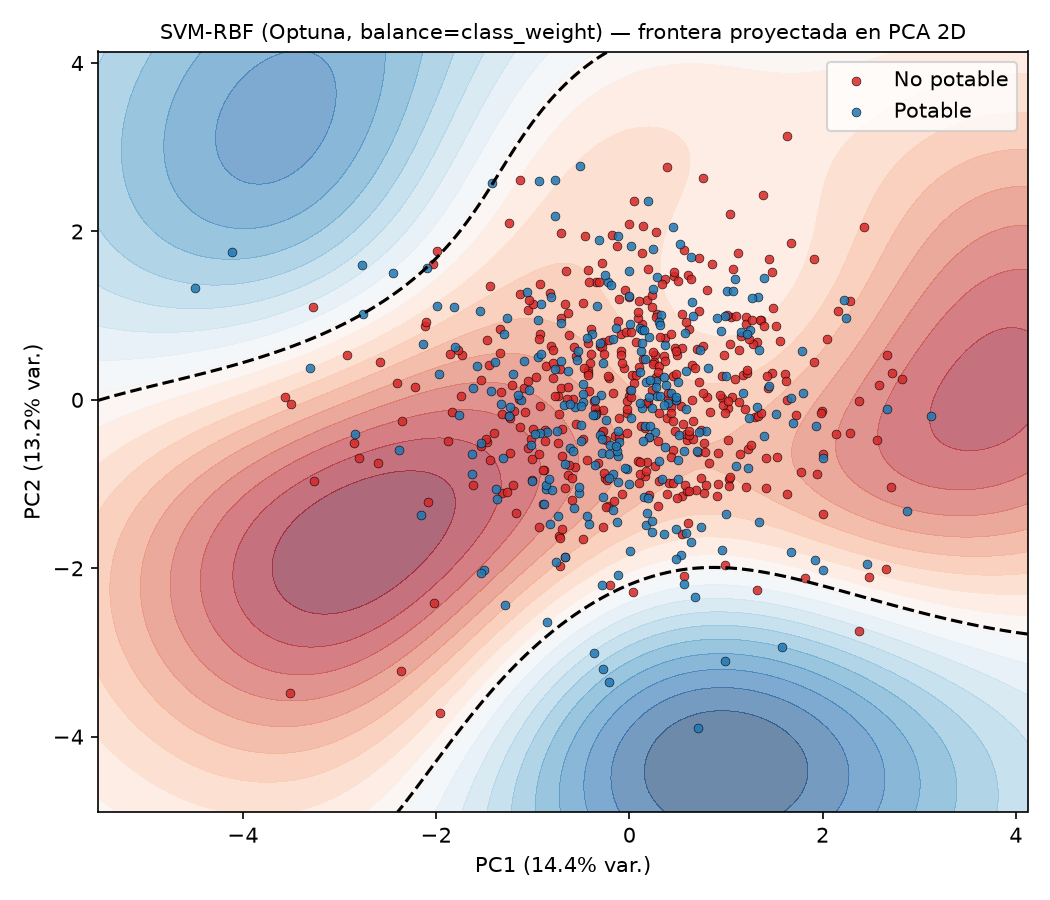

In [10]:
optuna_boundary_path = baseline.FIGURES_DIR / "fig_decision_boundary_optuna_pca.png"
explained_optuna = plot_2d_decision_boundary(
    best_pipeline, X_test, y_test,
    f"SVM-RBF (Optuna, balance={optuna_metrics['best_params']['balance_strategy']}) — frontera proyectada en PCA 2D",
    optuna_boundary_path,
)
print(f"Varianza explicada por PC1+PC2: {explained_optuna.sum():.1%}")
display(Image(filename=str(optuna_boundary_path)))

## Nota honesta sobre estas figuras

PC1+PC2 explican solo una fracción de la varianza total (ver los porcentajes impresos arriba) —
la proyección 2D es una aproximación gruesa de la frontera real en 9 dimensiones, no una
representación completa ni una prueba cuantitativa. Sirve para intuición visual (¿hay estructura
separable a simple vista?, ¿la frontera del modelo optimizado se ve más suave o menos errática
que la del grid search?), pero las métricas de las secciones anteriores siguen siendo la
evidencia real de qué modelo es mejor.